In [17]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import os

In [18]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

image_size = 64
latent_dim = 128
batch_size = 64
epochs = 50

lr = 0.0002
beta1 = 0.0
beta2 = 0.99

Using device: mps


In [19]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5])
])

def rgba_loader(path):
    return Image.open(path).convert("RGBA")

dataset = torchvision.datasets.ImageFolder(
    root="../testCreateDataSet/pokemonResize",
    transform=transform,
    loader=rgba_loader
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

In [20]:
class MappingNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,256)
        )

    def forward(self,x):
        return self.net(x)

In [21]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(256,512,4,1,0),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64,4,4,2,1),
            nn.Tanh()
        )

    def forward(self,w):

        w = w.view(-1,256,1,1)

        return self.net(w)

In [22]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(4,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x).view(-1)

In [23]:
G = Generator().to(device)
D = Discriminator().to(device)
M = MappingNetwork().to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(
    list(G.parameters()) + list(M.parameters()),
    lr=lr,
    betas=(beta1,beta2)
)

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(beta1,beta2)
)

In [24]:
for epoch in range(epochs):

    for real,_ in tqdm(loader):

        real = real.to(device)
        b = real.size(0)

        real_label = torch.ones(b).to(device)
        fake_label = torch.zeros(b).to(device)

        # Train Discriminator

        opt_D.zero_grad()

        out_real = D(real)
        loss_real = criterion(out_real,real_label)

        z = torch.randn(b,latent_dim).to(device)
        w = M(z)

        fake = G(w)

        out_fake = D(fake.detach())
        loss_fake = criterion(out_fake,fake_label)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # Train Generator

        opt_G.zero_grad()

        out = D(fake)

        loss_G = criterion(out,real_label)
        loss_G.backward()

        opt_G.step()

    print(epoch,loss_D.item(),loss_G.item())

100%|██████████| 19/19 [00:18<00:00,  1.02it/s]


0 0.15466755628585815 5.4283528327941895


100%|██████████| 19/19 [00:13<00:00,  1.45it/s]


1 0.08657503128051758 6.554740905761719


100%|██████████| 19/19 [00:13<00:00,  1.42it/s]


...

47 1.3892301321029663 2.76155948638916


100%|██████████| 19/19 [00:13<00:00,  1.43it/s]


48 0.9637856483459473 1.004940390586853


100%|██████████| 19/19 [00:12<00:00,  1.47it/s]

49 1.342000126838684 0.7790390253067017


(np.float64(-0.5), np.float64(529.5), np.float64(529.5), np.float64(-0.5))

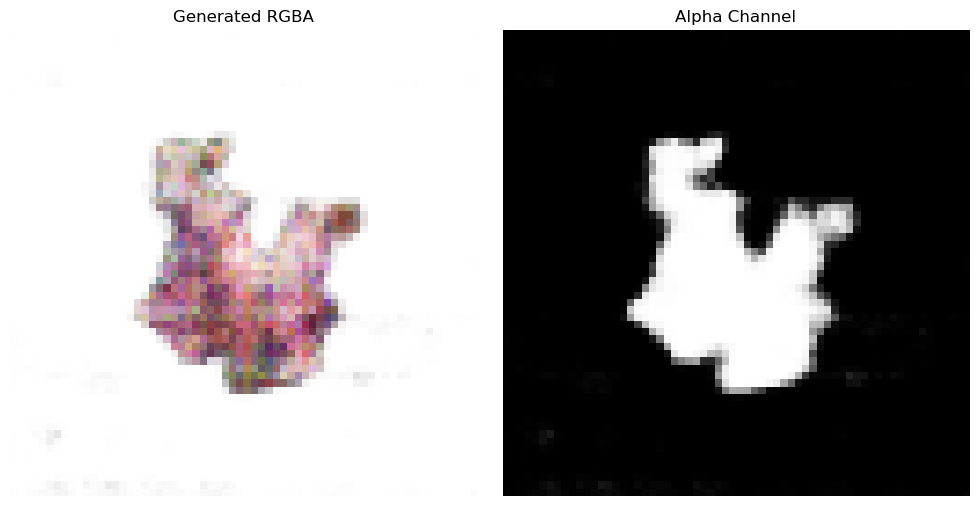

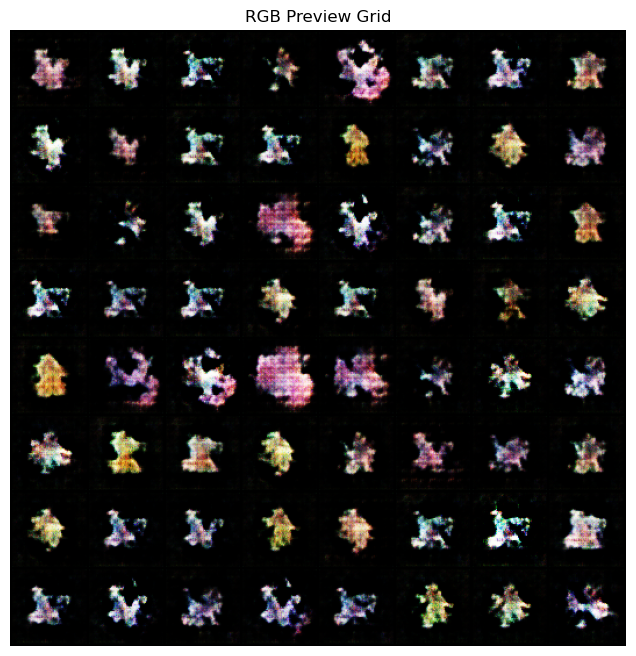

In [25]:
z = torch.randn(64, latent_dim).to(device)
w = M(z)
fake = G(w).detach().cpu()

# Convert from [-1, 1] to [0, 1] for visualization.
fake_vis = (fake + 1) / 2
fake_vis = fake_vis.clamp(0, 1)

# Show one sample as RGBA + its alpha mask.
sample_rgba = fake_vis[0].permute(1, 2, 0).numpy()
sample_alpha = fake_vis[0, 3].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_rgba)
axes[0].set_title("Generated RGBA")
axes[0].axis("off")

axes[1].imshow(sample_alpha, cmap="gray")
axes[1].set_title("Alpha Channel")
axes[1].axis("off")
plt.tight_layout()

# Optional: RGB grid preview for quick batch inspection.
rgb_grid = torchvision.utils.make_grid(fake_vis[:, :3], nrow=8)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_grid.permute(1, 2, 0))
plt.title("RGB Preview Grid")
plt.axis("off")